In [4]:
import bagpy
from bagpy import bagreader
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

/opt/ros/noetic/lib/python3/dist-packages/rosbag/bag.py:1568: SyntaxWarning: invalid escape sequence '\d'
  matches = re.match("#ROS(.*) V(\d).(\d)", version_line)


In [81]:
def read_pose_from_bag(bag, name_topic, name_x, name_y):
    df = pd.read_csv(bag.message_by_topic(name_topic))
    
    # try to get a time axis; fall back to sample index
    if {'header.stamp.secs', 'header.stamp.nsecs'}.issubset(df.columns):
        t = (df['header.stamp.secs'].to_numpy(dtype=float) +
             df['header.stamp.nsecs'].to_numpy(dtype=float) * 1e-9)
    else:
        t = np.arange(len(df), dtype=float)

    pose = np.vstack([df[name_x].to_numpy(), df[name_y].to_numpy()]).T
    print(f"read pose {name_topic}", pose.shape)
    return t, pose

bag = bagreader('/home/henrypcl/mocap_data_analy.bag')
print(bag.topic_table)

[INFO]  Data folder /home/henrypcl/mocap_data_analy already exists. Not creating.
                                   Topics  \
0                                 /rosout   
1                             /rosout_agg   
2                  /tbot162/battery_state   
3                        /tbot162/cmd_vel   
4                  /tbot162/cmd_vel_rc100   
5            /tbot162/controller_log_info   
6                    /tbot162/diagnostics   
7               /tbot162/firmware_version   
8           /tbot162/global_leader_states   
9                            /tbot162/imu   
10                  /tbot162/joint_states   
11                /tbot162/magnetic_field   
12                          /tbot162/odom   
13  /tbot162/robot_pose_ekf/odom_combined   
14                  /tbot162/sensor_state   
15                /tbot162/tag_detections   
16                  /tbot162/version_info   
17                     /tbot162/wheelodom   
18                 /tbot205/battery_state   
19                

read pose /tbot162/odom (1570, 2)
read pose /tbot162/robot_pose_ekf/odom_combined (1660, 2)


(-0.09191455641994258,
 2.0126154489931647,
 -0.08239735935310238,
 1.7308035058615552)

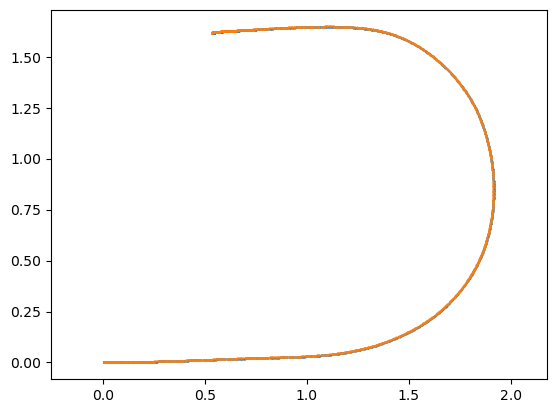

In [82]:
_, pose_162_odom = read_pose_from_bag(bag,
                                    '/tbot162/odom',
                                    'pose.pose.position.x',
                                    'pose.pose.position.y')
_, pose_162_ekf_odom = read_pose_from_bag(bag,
                                    '/tbot162/robot_pose_ekf/odom_combined',
                                    'pose.pose.position.x',
                                    'pose.pose.position.y')
plt.plot(pose_162_odom[:,0],pose_162_odom[:,1], '.', markersize='1')
plt.plot(pose_162_ekf_odom[:,0],pose_162_ekf_odom[:,1], '.', markersize='1')
plt.axis('equal')

In [96]:
t162, p162_m = read_pose_from_bag(bag,
                                    '/vrpn_client_node/bot162/pose',
                                    'pose.position.x',
                                    'pose.position.y')
t205, p205_m = read_pose_from_bag(bag,
                                    '/vrpn_client_node/bot205/pose',
                                    'pose.position.x',
                                    'pose.position.y')
# plt.plot(p162_m[:,0],p162_m[:,1], '.', markersize='1')
# plt.plot(p205_m[:,0],p205_m[:,1], '.', markersize='1')
# plt.axis('equal')

read pose /vrpn_client_node/bot162/pose (6761, 2)
read pose /vrpn_client_node/bot205/pose (6739, 2)


Text(0.5, 1.0, 'Equal-spaced trim')

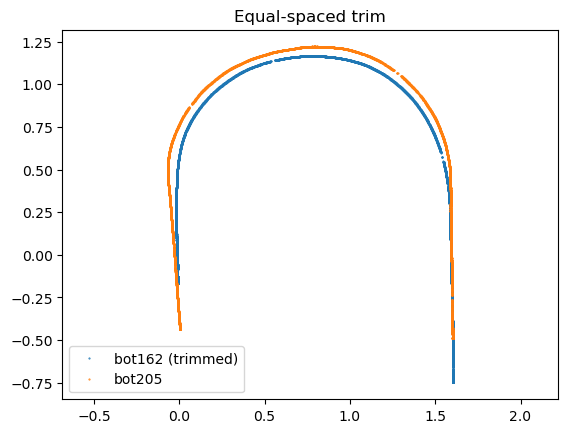

In [103]:
def equal_trim_to_match(t1, p1, t2, p2):
    """Evenly downsample the longer sequence to match the shorter length."""
    n1, n2 = len(p1), len(p2)
    if n1 == n2:
        return t1, p1, t2, p2
    if n1 > n2:
        idx = np.linspace(0, n1 - 1, n2, dtype=int)
        return t1[idx], p1[idx], t2, p2
    else:
        idx = np.linspace(0, n2 - 1, n1, dtype=int)
        return t1, p1, t2[idx], p2[idx]

t162_t, p162_t, t205_t, p205_t = equal_trim_to_match(t162, p162_m, t205, p205_m)

plt.figure()
plt.plot(p162_t[:, 0], p162_t[:, 1], '.', markersize=1, label='bot162 (trimmed)')
plt.plot(p205_t[:, 0], p205_t[:, 1], '.', markersize=1, label='bot205')
plt.axis('equal'); plt.legend(); plt.title('Equal-spaced trim')

Text(0, 0.5, 'spacing Error')

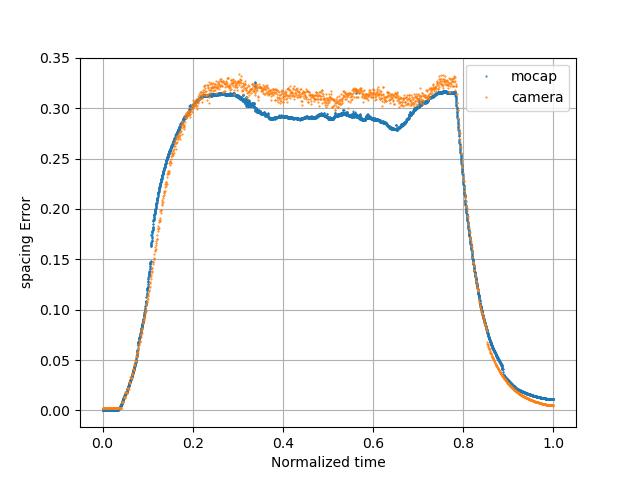

In [127]:
# Spacing error from mocap
error_m = np.linalg.norm(p162_t - p205_t, axis=1)
error_m -= error_m[0]
t_m = np.linspace(0, 1, len(error_m), dtype=float)

# Spacing error from camera
topic_msg = pd.read_csv(bag.message_by_topic('/tbot162/controller_log_info'))
error_c = topic_msg['data_0'].to_numpy()
t_c = np.linspace(0, 1, len(error_c), dtype=float)

# %matplotlib inline
%matplotlib widget
plt.figure()
plt.plot(t_m, error_m, '.', markersize='1', label='mocap')
plt.plot(t_c, error_c, '.', markersize='1', label='camera')
plt.grid(); plt.legend()
plt.xlabel('Normalized time')
plt.ylabel('spacing Error')